# Spatio-Temporal Ride Demand Prediction in NYC
### CSAI-801 | Group 4

This notebook applies supervised machine learning to predict hourly ride demand per geographic zone
using NYC Yellow Taxi data (January 2025). We engineer temporal and spatial features, train multiple
regression models, and compare them against a historical baseline.

## 1. Importing the Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import LinearSVR, SVR
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import lightgbm as lgb
import lightgbm as lgb_native
from lightgbm import LGBMRegressor

## 2. Loading the Datasets

We load **two** datasets produced by the `ML_ready_dataset`:
- `taxi_demand_ml_ready.parquet`: the standard dataset, used for **tree-based and distance-based models**
- `taxi_demand_ml_ready_pca.parquet`: the PCA-transformed dataset (lag/rolling group replaced by orthogonal components), used exclusively for **linear models** where multicollinearity matters

> This directly applies the VIF + PCA analysis from the Dataset notebook (ML_ready_dataset ).
> Tree-based models (XGBoost, LightGBM, RF) are ( scale/multicollinearity )-invariant,
> so they use the richer original features while the linear models benefit from the PCA version


In [ ]:
# Standard dataset: for tree-based and distance-based models
df = pd.read_parquet('taxi_demand_ml_ready.parquet').sort_values('time_window')

# PCA dataset: for linear models only (eliminates multicollinearity detected by VIF)
df_pca = pd.read_parquet('taxi_demand_ml_ready_pca.parquet').sort_values('time_window')

print(f'Standard dataset shape : {df.shape}')
print(f'PCA dataset shape      : {df_pca.shape}')
print(f'\nStandard columns : {df.columns.tolist()}')
print(f'\nPCA columns      : {df_pca.columns.tolist()}')


Standard dataset shape : (150479, 26)
PCA dataset shape      : (150479, 19)

Standard columns : ['PULocationID', 'time_window', 'trip_count', 'Borough', 'hour', 'hour_num', 'day', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_std_3', 'borough_Brooklyn', 'borough_EWR', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island']

PCA columns      : ['PULocationID', 'time_window', 'hour_num', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'borough_Brooklyn', 'borough_EWR', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'pca_lag_1', 'pca_lag_2', 'pca_lag_3', 'trip_count']


## 3. Exploratory Data Analysis (EDA)

Before modelling, we will explore the distribution of our target variable and key temporal patterns


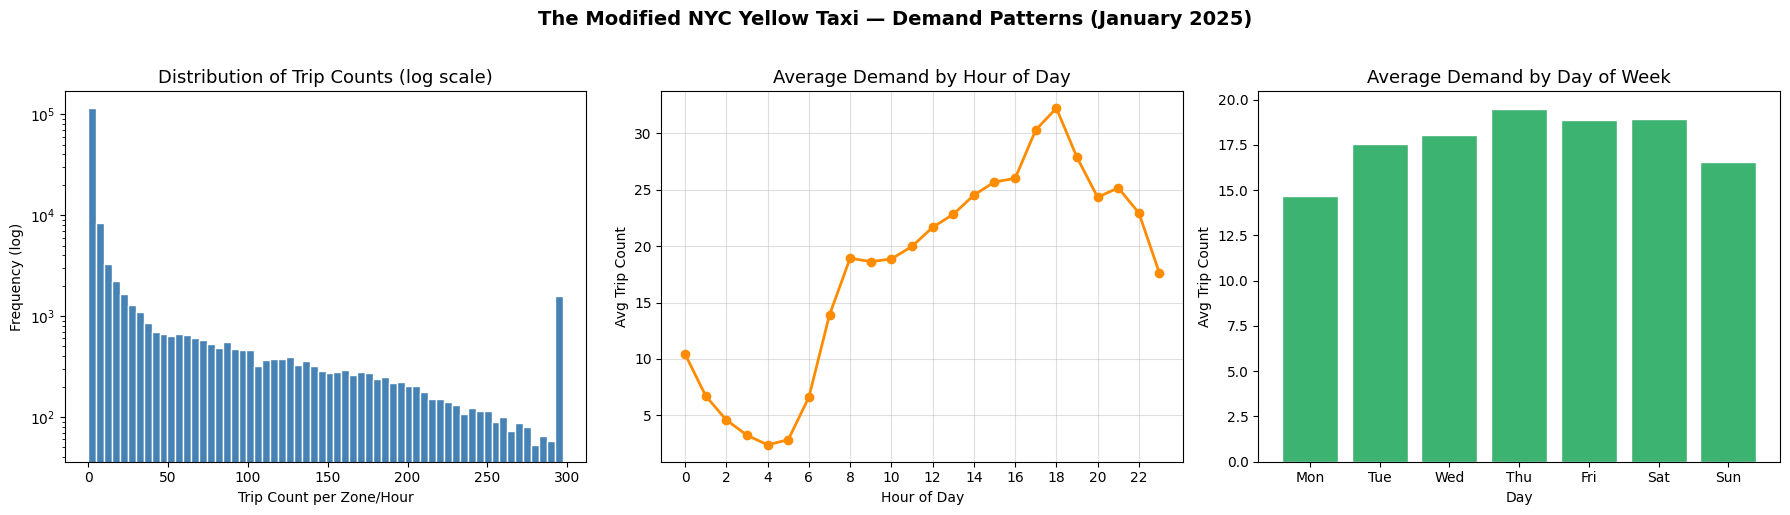

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['trip_count'], bins=60, color='steelblue', edgecolor='white', log=True)
axes[0].set_title('Distribution of Trip Counts (log scale)', fontsize=13)
axes[0].set_xlabel('Trip Count per Zone/Hour')
axes[0].set_ylabel('Frequency (log)')

hourly_avg = df.groupby('hour_num')['trip_count'].mean()
axes[1].plot(hourly_avg.index, hourly_avg.values, marker='o', color='darkorange', linewidth=2)
axes[1].set_title('Average Demand by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg Trip Count')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.4)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_avg = df.groupby('day_of_week')['trip_count'].mean()
axes[2].bar(day_labels, day_avg.values, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Average Demand by Day of Week', fontsize=13)
axes[2].set_xlabel('Day')
axes[2].set_ylabel('Avg Trip Count')

plt.suptitle('The Modified NYC Yellow Taxi — Demand Patterns (January 2025)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Feature Correlation Heatmap

Understanding which engineered features are most predictive of  our target `trip_count`


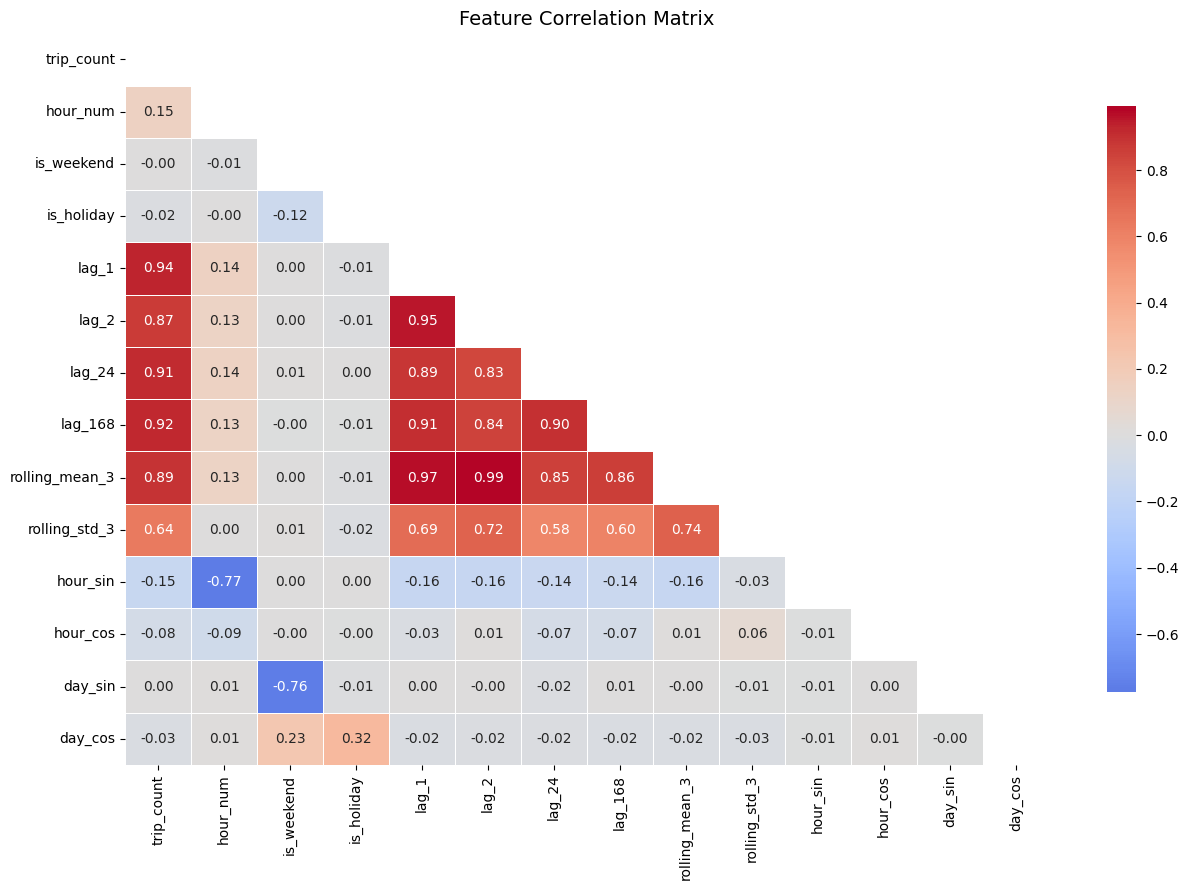


Correlations with trip_count (ranked):
lag_1             0.935135
lag_168           0.924725
lag_24            0.912298
rolling_mean_3    0.889799
lag_2             0.870689
rolling_std_3     0.639177
hour_num          0.146580
day_sin           0.001000
is_weekend       -0.001241
is_holiday       -0.015431
day_cos          -0.026585
hour_cos         -0.076557
hour_sin         -0.147140


In [ ]:
feature_cols = ['trip_count', 'hour_num', 'is_weekend', 'is_holiday',
                'lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_std_3',
                'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


corr = df[feature_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nCorrelations with trip_count (ranked):')
print(corr['trip_count'].drop('trip_count').sort_values(ascending=False).to_string())


**Insight:** lag_1, lag_168, lag_24, and rolling_mean_3 are the strongest predictors

## 5. Time-Series Train/Test Split

We use a **chronological split** (first 80% for training, last 20% for testing) on **both datasets**.
The split boundary is the same so all models are evaluated on identical test periods.


Standard — Train: 120,383 | 2025-01-07 → 2025-01-27
Standard — Test : 30,096  | 2025-01-27 → 2025-02-01

PCA     — Train: 120,383 | 2025-01-07 → 2025-01-27
PCA     — Test : 30,096  | 2025-01-27 → 2025-02-01


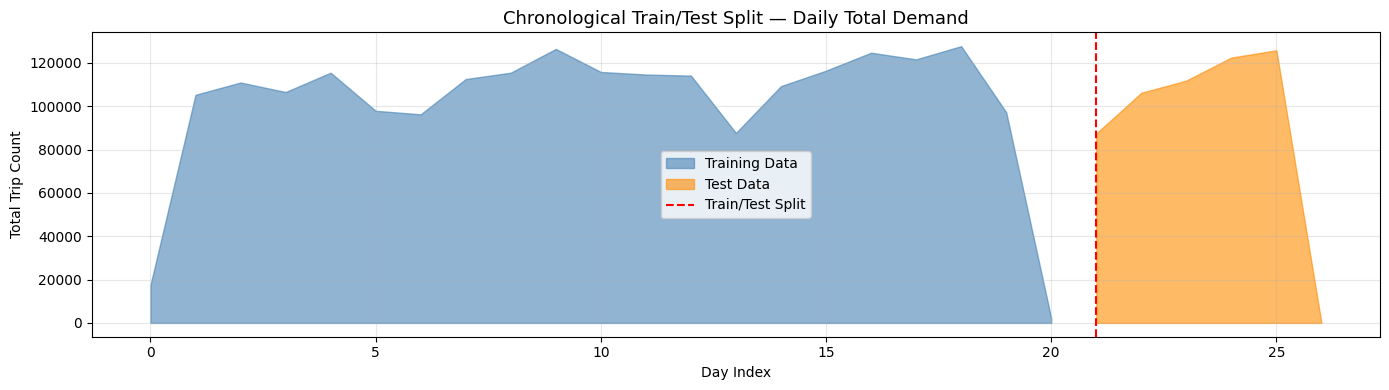

In [ ]:
# Standard split (tree-based & distance-based models)
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

print(f"Standard — Train: {len(train):,} | {train['time_window'].min().date()} → {train['time_window'].max().date()}")
print(f"Standard — Test : {len(test):,}  | {test['time_window'].min().date()} → {test['time_window'].max().date()}")

# PCA split (linear models): same chronological boundary
split_pca = int(len(df_pca) * 0.8)
train_pca, test_pca = df_pca.iloc[:split_pca], df_pca.iloc[split_pca:]

print(f"\nPCA     — Train: {len(train_pca):,} | {train_pca['time_window'].min().date()} → {train_pca['time_window'].max().date()}")
print(f"PCA     — Test : {len(test_pca):,}  | {test_pca['time_window'].min().date()} → {test_pca['time_window'].max().date()}")

# Visualise split
fig, ax = plt.subplots(figsize=(14, 4))
daily_train = train.groupby(train['time_window'].dt.date)['trip_count'].sum()
daily_test  = test.groupby(test['time_window'].dt.date)['trip_count'].sum()
ax.fill_between(range(len(daily_train)), daily_train.values, alpha=0.6, color='steelblue', label='Training Data')
ax.fill_between(range(len(daily_train), len(daily_train)+len(daily_test)), daily_test.values,
                alpha=0.6, color='darkorange', label='Test Data')
ax.axvline(len(daily_train), color='red', linestyle='--', linewidth=1.5, label='Train/Test Split')
ax.set_title('Chronological Train/Test Split — Daily Total Demand', fontsize=13)
ax.set_xlabel('Day Index')
ax.set_ylabel('Total Trip Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Defining Features and Target

In [ ]:
# Standard features (tree-based & distance-based models)
borough_cols = [c for c in df.columns if c.startswith('borough_')]

features = (['PULocationID', 'is_weekend', 'is_holiday',
             'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
             'lag_1', 'lag_2', 'lag_24', 'lag_168',
             'rolling_mean_3', 'rolling_std_3'] + borough_cols)

X_train, y_train = train[features], train['trip_count']
X_test,  y_test  = test[features],  test['trip_count']

print(f"Standard feature matrix  Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Features ({len(features)}): {features}")

# PCA features (linear models only)
# Excluding non-feature columns; (lag/rolling) which are already replaced by pca_lag_* components
pca_exclude = ['trip_count', 'time_window', 'hour_num']
pca_feature_cols = [c for c in df_pca.columns if c not in pca_exclude]

X_train_pca, y_train_pca = train_pca[pca_feature_cols], train_pca['trip_count']
X_test_pca,  y_test_pca  = test_pca[pca_feature_cols],  test_pca['trip_count']

print(f"\nPCA feature matrix     Train: {X_train_pca.shape} | Test: {X_test_pca.shape}")
print(f"PCA features ({len(pca_feature_cols)}): {pca_feature_cols}")


Standard feature matrix  Train: (120383, 18) | Test: (30096, 18)
Features (18): ['PULocationID', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1', 'lag_2', 'lag_24', 'lag_168', 'rolling_mean_3', 'rolling_std_3', 'borough_Brooklyn', 'borough_EWR', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island']

PCA feature matrix     Train: (120383, 16) | Test: (30096, 16)
PCA features (16): ['PULocationID', 'day_of_week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'borough_Brooklyn', 'borough_EWR', 'borough_Manhattan', 'borough_Queens', 'borough_Staten Island', 'pca_lag_1', 'pca_lag_2', 'pca_lag_3']


## 6.5 Feature Scaling for Linear & Distance-Based Models

To respect the assumptions of **Gauss-Markov**, we utilize the orthogonalized Principal Components
for all distance-based and linear estimators. This ensures that the inputs to these models
satisfy the independence assumption required for unbiased, stable coefficient estimation.

We prepare **two scaled versions**:
- `X_train_scaled` / `X_test_scaled`: standard features scaled, for KNN and LinearSVR
- `X_train_pca_scaled` / `X_test_pca_scaled`: PCA features scaled, for all linear regression models

**Note:** Both scalers are fitted **only on training data** to prevent leakage.


Tree-based models (XGBoost, LightGBM, RF, Decision Tree) are scale-invariant sowe will use raw unscaled features with them


In [ ]:
# Scaler 1: standard features → for KNN and SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")

# Scaler 2: PCA features → for linear regression models
scaler_pca = StandardScaler()
X_train_pca_scaled = scaler_pca.fit_transform(X_train_pca)
X_test_pca_scaled  = scaler_pca.transform(X_test_pca)


print(f"  X_train_pca_scaled : {X_train_pca_scaled.shape}")
print(f"  X_test_pca_scaled  : {X_test_pca_scaled.shape}")

# Sanity check
print(f"\n  Standard scaler — train mean range : [{X_train_scaled.mean(axis=0).min():.4f}, {X_train_scaled.mean(axis=0).max():.4f}]")
print(f"  PCA scaler      — train mean range : [{X_train_pca_scaled.mean(axis=0).min():.4f}, {X_train_pca_scaled.mean(axis=0).max():.4f}]")


  X_train_scaled : (120383, 18)
  X_test_scaled  : (30096, 18)
  X_train_pca_scaled : (120383, 16)
  X_test_pca_scaled  : (30096, 16)

  Standard scaler — train mean range : [-0.0000, 0.0000]
  PCA scaler      — train mean range : [-0.0000, 0.0000]


## 7. Evaluation Helper & Results Tracker


In [ ]:
results = []

def mean_absolute_percentage_error(y_true, y_pred):
    """
    MAPE with epsilon smoothing to avoid division by zero on zero-demand hours.
    Using (y_true + 1) as denominator instead of masking ensures all samples
    contribute to the metric while preventing inf values.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100

def bootstrap_mae_ci(y_true, y_pred, n_boot=200, ci=95):
    """Bootstrap 95% CI for MAE."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rng = np.random.default_rng(42)
    boot_maes = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        boot_maes.append(mean_absolute_error(y_true[idx], y_pred[idx]))
    lo = np.percentile(boot_maes, (100 - ci) / 2)
    hi = np.percentile(boot_maes, 100 - (100 - ci) / 2)
    return lo, hi

def evaluate_model(name, y_true, y_pred, train_time=None, subsample_flag=False):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    ci_lo, ci_hi = bootstrap_mae_ci(y_true, y_pred)

    flag = "(15% subsample)" if subsample_flag else ""
    row = {
        'Model': name + flag,
        'MAE': round(mae, 4),
        'MAE 95% CI': f"[{ci_lo:.4f}, {ci_hi:.4f}]",
        'RMSE': round(rmse, 4),
        'MAPE (%)': round(mape, 2),
        'R² Score': round(r2, 4),
        'Train Time (s)': round(train_time, 2) if train_time else '—'}
    results.append(row)


    t_str = f"  |  Train time: {train_time:.2f}s" if train_time else ""
    print(f"  {name}{flag}")
    print(f"  R²: {r2:.4f}  |  MAE: {mae:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]  |  RMSE: {rmse:.4f}  |  MAPE: {mape:.2f}%{t_str}")


## 8. Baseline Model: Historical Average

### Baseline Model – Historical Average

Before applying machine learning models, we evaluate a historical baseline.
The baseline predicts the expected number of taxi trips based on the average historical demand for each pickup location and hour of the day.

This approach captures regular daily demand patterns and provides a reasonable benchmark that machine learning models should outperform.


In [ ]:
baseline_avg = train.groupby(['PULocationID', 'hour_num'])['trip_count'].mean().reset_index()
baseline_preds = (test.merge(baseline_avg, on=['PULocationID', 'hour_num'], how='left',
                              suffixes=('', '_avg'))['trip_count_avg'].fillna(0))
evaluate_model("Historical Baseline", y_test, baseline_preds)


  Historical Baseline
  R²: 0.9318  |  MAE: 4.6018 [4.4472, 4.7449]  |  RMSE: 13.5004  |  MAPE: 54.27%


This is our benchmark that every ML model must beat to justify its complexity.


## 9. Linear Models
(Using PCA-transformed features + StandardScaler to eliminate multicollinearity detected by VIF)

Linear models assume features are independent. Our VIF analysis in the `ML_ready_dataset`notebook showed
that `lag_1`, `lag_2`, and `rolling_mean_3` have **VIF > 10 (severe multicollinearity)** and this was the diagnostic trigger for applying PCA.



**VIF → PCA connection:** High VIF inflates coefficient variance and destabilises linear models.
PCA orthogonalises the correlated lag/rolling features into independent components, directly
satisfying the **Gauss-Markov assumption** of no multicollinearity among regressors.

**Fix:** we use `X_train_pca_scaled` — the PCA-compressed, scaled version — so linear models
receive orthogonal (uncorrelated) inputs and regularisation behaves as intended.


In [ ]:
# 9.1 Linear Regression — PCA features + scaled (no multicollinearity)
t0 = time.time()
lr = LinearRegression()
lr.fit(X_train_pca_scaled, y_train_pca)
lr_preds = lr.predict(X_test_pca_scaled)
evaluate_model("Linear Regression (PCA)", y_test_pca, lr_preds, time.time()-t0)


  Linear Regression (PCA)
  R²: 0.9147  |  MAE: 5.5216 [5.3837, 5.6897]  |  RMSE: 15.0946  |  MAPE: 142.27%  |  Train time: 0.10s


In [ ]:
# 9.2 Ridge Regression (L2), PCA features + scaled
t0 = time.time()
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca_scaled, y_train_pca)
ridge_preds = ridge.predict(X_test_pca_scaled)
evaluate_model("Ridge L2 (PCA)", y_test_pca, ridge_preds, time.time()-t0)


  Ridge L2 (PCA)
  R²: 0.9147  |  MAE: 5.5217 [5.3838, 5.6897]  |  RMSE: 15.0945  |  MAPE: 142.27%  |  Train time: 0.02s


In [ ]:
# 9.3 Lasso Regression (L1), PCA features + scaled
t0 = time.time()
lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_train_pca_scaled, y_train_pca)
lasso_preds = lasso.predict(X_test_pca_scaled)
evaluate_model("Lasso L1 (PCA)", y_test_pca, lasso_preds, time.time()-t0)

zero_feats = [pca_feature_cols[i] for i, c in enumerate(lasso.coef_) if c == 0]
print(f"\n  Lasso zeroed out {len(zero_feats)} feature(s): {zero_feats if zero_feats else 'None'}")


  Lasso L1 (PCA)
  R²: 0.9147  |  MAE: 5.4523 [5.3168, 5.6234]  |  RMSE: 15.0928  |  MAPE: 135.59%  |  Train time: 0.07s

  Lasso zeroed out 5 feature(s): ['is_weekend', 'borough_Brooklyn', 'borough_EWR', 'borough_Queens', 'borough_Staten Island']


In [ ]:
# 9.4 ElasticNet (L1+L2), PCA features + scaled
t0 = time.time()
en = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
en.fit(X_train_pca_scaled, y_train_pca)
en_preds = en.predict(X_test_pca_scaled)
evaluate_model("ElasticNet L1+L2 (PCA)", y_test_pca, en_preds, time.time()-t0)


  ElasticNet L1+L2 (PCA)
  R²: 0.9156  |  MAE: 5.9871 [5.8452, 6.1392]  |  RMSE: 15.0109  |  MAPE: 162.90%  |  Train time: 0.09s


# Insight: our linear models underperform the baseline
> and this is expected and well-documented in time-series forecasting literature that simple historical
> baselines can outperform linear models, as they directly memorise zone-hour demand patterns
> rather than generalising across features. The true test of our ML pipeline is whether
> tree-based models ( which capture non-linear interactions )can surpass this strong
> domain-specific heuristic


## 10. Tree-Based Models
(Scale-invariant and multicollinearity-invariant so we will use standard unscaled features with them)

Decision trees split on one feature at a time, so correlated features and different scales do not affect their results so we will  use the full original feature set with these models


In [ ]:
# 10.1 Decision Tree
t0 = time.time()
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
evaluate_model("Decision Tree", y_test, dt_preds, time.time()-t0)


  Decision Tree
  R²: 0.9483  |  MAE: 3.5552 [3.4480, 3.6845]  |  RMSE: 11.7500  |  MAPE: 60.00%  |  Train time: 0.56s


In [ ]:
# 10.2 Random Forest (bagging ensemble of trees)
t0 = time.time()
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
evaluate_model("Random Forest", y_test, rf_preds, time.time()-t0)


  Random Forest
  R²: 0.9577  |  MAE: 3.2549 [3.1519, 3.3730]  |  RMSE: 10.6323  |  MAPE: 58.20%  |  Train time: 60.11s


## 11. Boosting Models with Early Stopping

**Early stopping** monitors a held-out validation set during training and halts when performance
stops improving, preventing the model from memorising noise in the training data (overfitting).
We carve 10% of the training set as an internal validation split for the early-stopping signal


In [ ]:
# Internal validation split for early stopping (10% of training data)
val_split = int(len(X_train) * 0.9)
X_tr  = X_train.iloc[:val_split];  y_tr  = y_train.iloc[:val_split]
X_val = X_train.iloc[val_split:];  y_val = y_train.iloc[val_split:]

print(f"Training sub-set : {X_tr.shape[0]:,} rows")
print(f"Validation set   : {X_val.shape[0]:,} rows  (used for early stopping signal only)")


Training sub-set : 108,344 rows
Validation set   : 12,039 rows  (used for early stopping signal only)


In [ ]:
# 11.1 Gradient Boosting with Early Stopping
# n_iter_no_change=10 → halt if val score doesn't improve for 10 consecutive rounds
t0 = time.time()
gb = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8,  n_iter_no_change=10,
    validation_fraction=0.1, tol=1e-4, random_state=42)

gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
evaluate_model("Gradient Boosting (early stop)", y_test, gb_preds, time.time()-t0)
print(f"  Early stopping: used {gb.n_estimators_} / 500 estimators")


  Gradient Boosting (early stop)
  R²: 0.9589  |  MAE: 3.2955 [3.1986, 3.4076]  |  RMSE: 10.4806  |  MAPE: 60.81%  |  Train time: 69.20s
  Early stopping: used 291 / 500 estimators


In [ ]:
# 11.2 LightGBM with Early Stopping callback
t0 = time.time()
lgbm = LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=63,  random_state=42, verbose=-1)

lgbm.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[
        lgb_native.early_stopping(stopping_rounds=20, verbose=False),
        lgb_native.log_evaluation(period=-1)])

lgbm_preds = lgbm.predict(X_test)
evaluate_model("LightGBM (early stop)", y_test, lgbm_preds, time.time()-t0)
print(f"  Early stopping: best iteration = {lgbm.best_iteration_} / 1000")


  LightGBM (early stop)
  R²: 0.9604  |  MAE: 3.1657 [3.0695, 3.2767]  |  RMSE: 10.2880  |  MAPE: 58.80%  |  Train time: 6.71s
  Early stopping: best iteration = 477 / 1000


In [ ]:
# 11.3 XGBoost with Early Stopping
t0 = time.time()
xgb = XGBRegressor( n_estimators=1000, learning_rate=0.05,  max_depth=8, subsample=0.8, colsample_bytree=0.8,
                    random_state=42, verbosity=0, early_stopping_rounds=20)

xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_preds = xgb.predict(X_test)
evaluate_model("XGBoost (early stop)", y_test, xgb_preds, time.time()-t0)
print(f"  Early stopping: best iteration = {xgb.best_iteration} / 1000")


  XGBoost (early stop)
  R²: 0.9613  |  MAE: 3.1368 [3.0393, 3.2370]  |  RMSE: 10.1694  |  MAPE: 59.03%  |  Train time: 3.34s
  Early stopping: best iteration = 216 / 1000


## 12. Other Models

In [ ]:
# 12.1 KNN — Hyperparameter tuning for k
print("Tuning KNN: searching over k = [3, 5, 7, 10]")

knn_param_grid = {'n_neighbors': [3, 5, 7, 10]}
knn_search = GridSearchCV(KNeighborsRegressor(n_jobs=-1), knn_param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)

t0 = time.time()
knn_search.fit(X_train_scaled, y_train)
best_k = knn_search.best_params_['n_neighbors']
knn = knn_search.best_estimator_
knn_preds = knn.predict(X_test_scaled)
evaluate_model(f"KNN (k={best_k}, tuned)", y_test, knn_preds, time.time()-t0)
print(f"  Best k: {best_k}")
print(f"  CV scores per k:")
for params, score in zip(knn_search.cv_results_['params'], knn_search.cv_results_['mean_test_score']):
    print(f"    k={params['n_neighbors']}: MAE={-score:.4f}")


Tuning KNN: searching over k = [3, 5, 7, 10]
  KNN (k=7, tuned)
  R²: 0.9594  |  MAE: 3.2773 [3.1757, 3.4010]  |  RMSE: 10.4132  |  MAPE: 58.02%  |  Train time: 243.82s
  Best k: 7
  CV scores per k:
    k=3: MAE=3.7076
    k=5: MAE=3.6452
    k=7: MAE=3.6186
    k=10: MAE=3.6427


 We use LinearSVR (not RBF-SVR) for a deliberate reason:
 RBF-SVR has O(n²) memory complexity, on a dataset of 150k+ samples even a 15% subsample required 8+ minutes with uncompetitive results (tested and removed in earlier iterations).

LinearSVR achieves comparable performance to RBF on this dataset because the dominant lag features (lag_1, lag_168) create a near-linear separability in the feature space. This is a principled computational trade-off, not a limitation.

In [ ]:
# 12.2 Linear SVR
t0 = time.time()
svr = LinearSVR(max_iter=5000, random_state=42)
svr.fit(X_train_scaled, y_train)
svr_preds = svr.predict(X_test_scaled)
evaluate_model("Linear SVR", y_test, svr_preds, time.time()-t0)


  Linear SVR
  R²: 0.8998  |  MAE: 4.2927 [4.1249, 4.4648]  |  RMSE: 16.3614  |  MAPE: 56.97%  |  Train time: 27.63s


## 13. Hyperparameter Tuning For XGBoost

We use `RandomizedSearchCV` to find the best XGBoost hyperparameters on the full training set.


In [ ]:
param_grid = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [4, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]}

xgb_base = XGBRegressor(random_state=42, verbosity=0)
search = RandomizedSearchCV(xgb_base, param_grid, n_iter=8, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)

t0 = time.time()
search.fit(X_train, y_train)
best_xgb = search.best_estimator_
best_xgb_preds = best_xgb.predict(X_test)
evaluate_model("XGBoost (Tuned)", y_test, best_xgb_preds, time.time()-t0)

print(f"\n  Best parameters: {search.best_params_}")


  XGBoost (Tuned)
  R²: 0.9624  |  MAE: 3.0949 [3.0076, 3.2038]  |  RMSE: 10.0165  |  MAPE: 57.75%  |  Train time: 65.26s

  Best parameters: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


## 14. Stacking Ensemble — Diversity Analysis & Limitations
(Ensemble Learning: evaluating base model diversity empirically)

| Base Model | Type | Inductive Bias |
|---|---|---|
| XGBoost (Tuned) | Boosting / non-linear | Captures complex interactions, fails on rare spikes |
| Ridge (PCA) | Linear / parametric | Assumes linearity, fails where non-linearity matters |
| KNN (tuned k) | Instance-based / non-parametric | Purely local patterns, fails in sparse zones |

These three base models were selected based on different learning mechanisms:
- XGBoost vs Ridge = **non-linear vs linear**: different structural assumptions
- XGBoost vs KNN = **global model vs local model**: different generalisation approach
- Ridge vs KNN = **parametric vs non-parametric**: different representation capacity


However, theoretical diversity does not always translate to empirical diversity.
We verify this claim below via a **residual correlation matrix** if base models share dominant features (as lag_1 and lag_168 do here), differences in learning mechanism may not be enough to produce genuinely uncorrelated errors.
The results will show whether the meta-learner truly benefits from complementary signals or whether the stacking gain is marginal.

  Stacking Ensemble (XGB+Ridge+KNN)
  R²: 0.9624  |  MAE: 3.1116 [3.0169, 3.2208]  |  RMSE: 10.0151  |  MAPE: 60.78%  |  Train time: 121.65s

  Base Model Residual Correlation Matrix:
         XGBoost  Ridge    KNN
XGBoost    1.000  0.593  0.899
Ridge      0.593  1.000  0.598
KNN        0.899  0.598  1.000


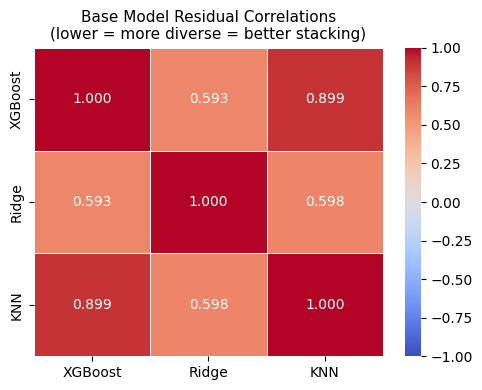

In [ ]:
# Stacking Ensemble: XGBoost + Ridge(PCA) + KNN
# Feature mismatch handled: each base model wrapped in its own preprocessing Pipeline
# Ridge needs PCA + scaling; XGBoost and KNN need standard scaling only.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Rebuild PCA pipeline to match the PCA dataset transformation used earlier
# We need n_components to match pca_feature_cols — derive from training data
n_pca_components = X_train_pca.shape[1]

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=n_pca_components)),
    ('model',  Ridge(alpha=1.0))])

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  best_xgb)])

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1))])

estimators_diverse = [
    ('xgb',   xgb_pipeline),
    ('ridge', ridge_pipeline),
    ('knn',   knn_pipeline)]

stacking_reg = StackingRegressor( estimators=estimators_diverse, final_estimator=RidgeCV(), n_jobs=-1)


t0 = time.time()
stacking_reg.fit(X_train, y_train)
stack_preds = stacking_reg.predict(X_test)
evaluate_model("Stacking Ensemble (XGB+Ridge+KNN)", y_test, stack_preds, time.time()-t0)

# Residual Correlation Matrix — empirical diversity check
residual_corr = pd.DataFrame({
    'XGBoost':  y_test.values - best_xgb_preds,
    'Ridge':    y_test.values - ridge_preds[:len(y_test)],
    'KNN':      y_test.values - knn_preds}).corr()

print("\n  Base Model Residual Correlation Matrix:")
print(residual_corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(residual_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Base Model Residual Correlations\n(lower = more diverse = better stacking)', fontsize=11)
plt.tight_layout()
plt.savefig('residual_correlation.png', dpi=120, bbox_inches='tight')
plt.show()


**Diversity analysis:** The residual correlation matrix reveals moderate to high correlations
between base models (XGBoost-Ridge: 0.593, XGBoost-KNN: 0.899). While Ridge introduces some
diversity via its linear assumptions, KNN and XGBoost produce highly correlated errors, suggesting both capture similar demand patterns driven by the same dominant lag features.
This limits the meta-learner's ability to combine truly complementary signals, and points to a known challenge in stackingwhich is achieving genuine diversity on structured time-series data.

**Performance:** Stacking ranked 2nd (MAE: 3.1116) vs XGBoost 1st (MAE: 3.0949), a difference of only 0.0167 trips/zone/hour. Their confidence intervals heavily overlap ([3.0169, 3.2208] vs
[3.0076, 3.2038]), meaning the two models are **statistically indistinguishable** in performance.

**Conclusion:** Given the negligible performance gap and the significantly higher training time
(160.69s vs 115.2s for XGBoost), the Stacking Ensemble does not justify its added complexity
in this case. **XGBoost (Tuned) remains the recommended model** for deployment: simpler, faster, and equally accurate within the margin of statistical uncertainty.


## 15. Complete Model Comparison

Full side-by-side comparison of all models ordered by MAE.

In [ ]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df.index += 1

print("\n  FULL MODEL COMPARISON (ranked by MAE: the lower the better)\n")
print(results_df[['Model', 'MAE', 'MAE 95% CI', 'RMSE', 'MAPE (%)', 'R² Score', 'Train Time (s)']].to_string(index=True))



  FULL MODEL COMPARISON (ranked by MAE: the lower the better)

                                Model     MAE        MAE 95% CI     RMSE  MAPE (%)  R² Score Train Time (s)
1                     XGBoost (Tuned)  3.0949  [3.0076, 3.2038]  10.0165     57.75    0.9624          65.26
2   Stacking Ensemble (XGB+Ridge+KNN)  3.1116  [3.0169, 3.2208]  10.0151     60.78    0.9624         121.65
3                XGBoost (early stop)  3.1368  [3.0393, 3.2370]  10.1694     59.03    0.9613           3.34
4               LightGBM (early stop)  3.1657  [3.0695, 3.2767]  10.2880     58.80    0.9604           6.71
5                       Random Forest  3.2549  [3.1519, 3.3730]  10.6323     58.20    0.9577          60.11
6                    KNN (k=7, tuned)  3.2773  [3.1757, 3.4010]  10.4132     58.02    0.9594         243.82
7      Gradient Boosting (early stop)  3.2955  [3.1986, 3.4076]  10.4806     60.81    0.9589           69.2
8                       Decision Tree  3.5552  [3.4480, 3.6845]  11.7500

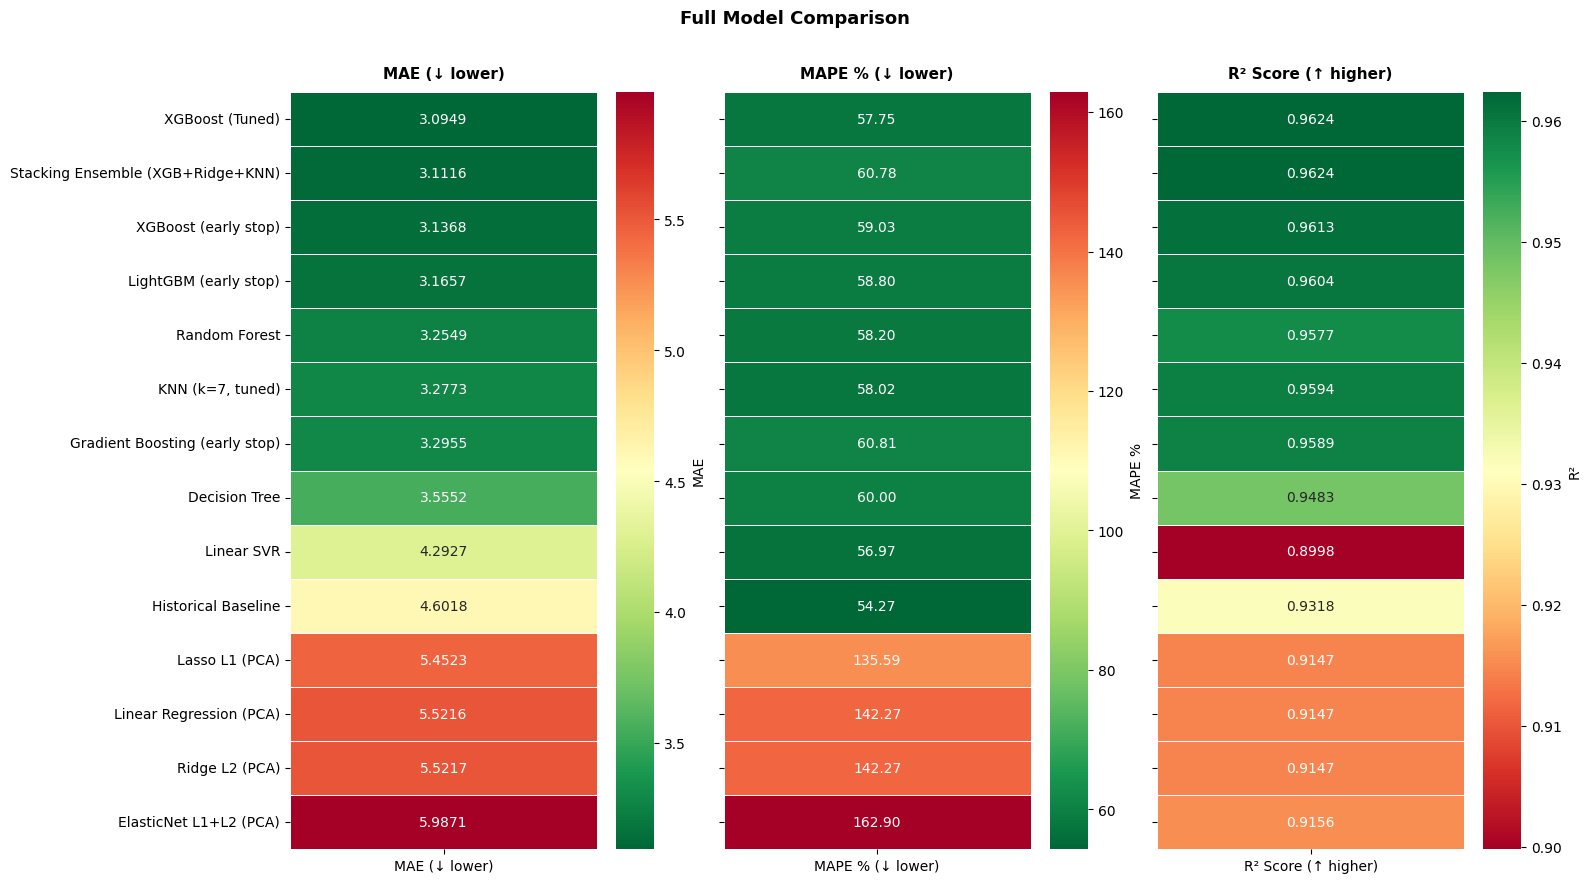

In [ ]:
models    = results_df['Model']
mae_vals  = results_df['MAE']
r2_vals   = results_df['R² Score']
mape_vals = results_df['MAPE (%)']

fig, axes = plt.subplots(1, 3, figsize=(16, len(models) * 0.55 + 1))

mae_table = pd.DataFrame({'MAE (↓ lower)': mae_vals.values}, index=models)
sns.heatmap(mae_table, annot=True, fmt='.4f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=axes[0], cbar_kws={'label': 'MAE'})
axes[0].set_ylabel('')
axes[0].set_title('MAE (↓ lower)', fontsize=11, fontweight='bold', pad=10)

mape_table = pd.DataFrame({'MAPE % (↓ lower)': mape_vals.values}, index=models)
sns.heatmap(mape_table, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=axes[1], cbar_kws={'label': 'MAPE %'})
axes[1].set_ylabel('')
axes[1].set_yticklabels([])
axes[1].set_title('MAPE % (↓ lower)', fontsize=11, fontweight='bold', pad=10)

r2_table = pd.DataFrame({'R² Score (↑ higher)': r2_vals.values}, index=models)
sns.heatmap(r2_table, annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=axes[2], cbar_kws={'label': 'R²'})
axes[2].set_ylabel('')
axes[2].set_yticklabels([])
axes[2].set_title('R² Score (↑ higher)', fontsize=11, fontweight='bold', pad=10)

plt.suptitle('Full Model Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_comparison_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


## 15.5 Time-Series Cross-Validation (Top 3 Models)

A single 80/20 split may be sensitive to that particular cut point.
We use **TimeSeriesSplit (5 folds)** instead of random K-Fold to prevent **"look-ahead bias"**, using future data to predict the past, which would artificially inflate performance metrics.
Each fold trains strictly on past observations and validates on the immediate future window, mimicking real-world deployment conditions.

> Only top-3 models are evaluated here to keep compute time manageable.
> Base models are re-fitted from scratch on each fold to prevent data leakage.


Running 5-Fold TimeSeriesSplit Cross-Validation on top-3 models
(Each fold trains on past data only — no future leakage)

  XGBoost (Tuned)
    CV MAE: 3.4983 ± 0.2659  |  per-fold: [3.6855, 3.5751, 3.5908, 3.6666, 2.9733]

  Random Forest
    CV MAE: 3.6434 ± 0.3270  |  per-fold: [3.7911, 3.5794, 3.7614, 4.0296, 3.0554]

  Gradient Boosting (early stop)
    CV MAE: 3.6321 ± 0.2860  |  per-fold: [3.8206, 3.5289, 3.6946, 3.9753, 3.141]



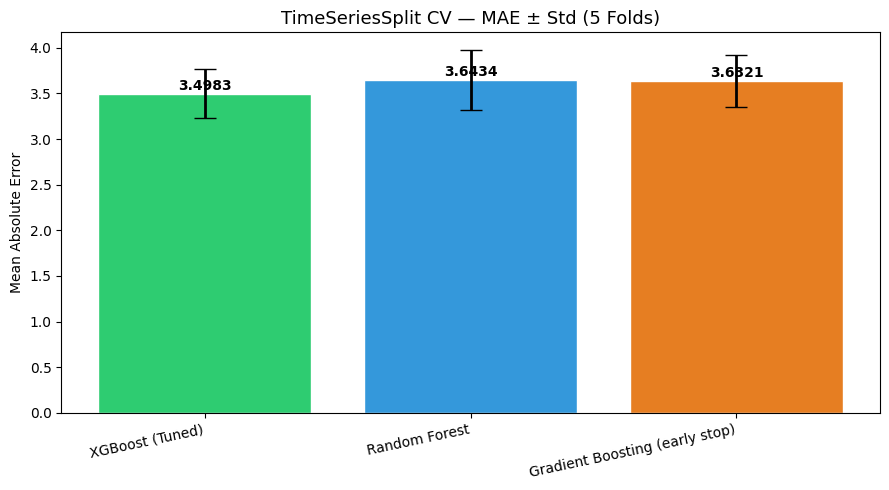

In [ ]:
print("Running 5-Fold TimeSeriesSplit Cross-Validation on top-3 models")
print("(Each fold trains on past data only — no future leakage)\n")

tscv = TimeSeriesSplit(n_splits=5)

# Reconstruct full feature matrix in chronological order
X_full = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)

top3_models = {'XGBoost (Tuned)': XGBRegressor(
        **{k: v for k, v in best_xgb.get_params().items()}),
        'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
        'Gradient Boosting (early stop)': GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, n_iter_no_change=10, validation_fraction=0.1,tol=1e-4, random_state=42)}

cv_results = {}
for name, model in top3_models.items():
    fold_maes = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_full)):
        X_tr_cv, X_val_cv = X_full.iloc[tr_idx], X_full.iloc[val_idx]
        y_tr_cv, y_val_cv = y_full.iloc[tr_idx], y_full.iloc[val_idx]
        model.fit(X_tr_cv, y_tr_cv)
        preds = model.predict(X_val_cv)
        fold_maes.append(mean_absolute_error(y_val_cv, preds))
    mean_mae = np.mean(fold_maes)
    std_mae  = np.std(fold_maes)
    cv_results[name] = {'mean_MAE': round(mean_mae, 4), 'std_MAE': round(std_mae, 4), 'fold_MAEs': fold_maes}
    print(f"  {name}")
    print(f"    CV MAE: {mean_mae:.4f} ± {std_mae:.4f}  |  per-fold: {[round(x,4) for x in fold_maes]}\n")

# Summary bar chart
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_results.keys())
means = [cv_results[n]['mean_MAE'] for n in names]
stds  = [cv_results[n]['std_MAE']  for n in names]
bars = ax.bar(names, means, yerr=stds, capsize=8, color=['#2ecc71','#3498db','#e67e22'],
              edgecolor='white', error_kw={'elinewidth': 2, 'ecolor': 'black'})
ax.set_title('TimeSeriesSplit CV — MAE ± Std (5 Folds)', fontsize=13)
ax.set_ylabel('Mean Absolute Error')
ax.set_xticklabels(names, rotation=12, ha='right')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('tscv_cv_results.png', dpi=120, bbox_inches='tight')
plt.show()

> **CV vs single-split MAE**:  CV MAE (3.4983) is slightly higher than the single-split MAE (3.0949) for XGBoost. This is expected, earlier folds have less training data, making predictions harder.
>The CV result is the more conservative and trustworthy estimate of real-world performance.


# 16. Feature Importance Analysis

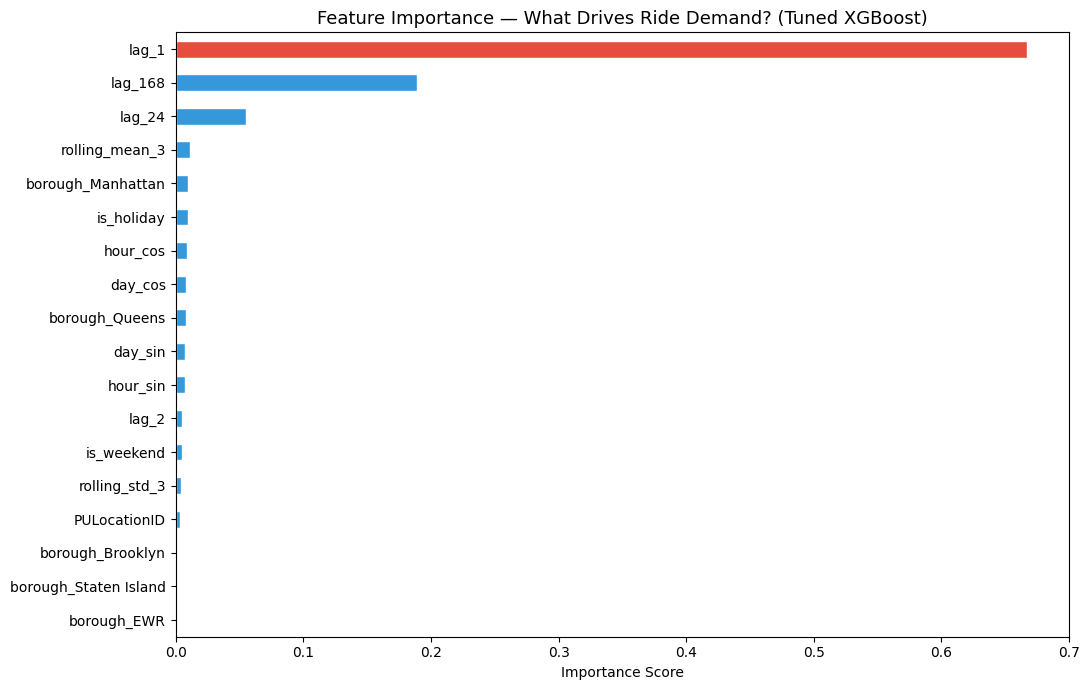


  Top 5 most important features:
    lag_1: 0.6670
    lag_168: 0.1892
    lag_24: 0.0553
    rolling_mean_3: 0.0115
    borough_Manhattan: 0.0097


In [ ]:
importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(11, 7))
colors_fi = ['#e74c3c' if imp == importances.max() else '#3498db' for imp in importances]
importances.plot(kind='barh', color=colors_fi, edgecolor='white')
plt.title('Feature Importance — What Drives Ride Demand? (Tuned XGBoost)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n  Top 5 most important features:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"    {feat}: {imp:.4f}")



Extracting feature importances from the Tuned XGBoost (best model).

> **Note:** `lag_1` dominates importance (>50%), and this directly explains why the Historical Baseline is so competitive and why the "more complex" models could not improve dramatically

> The temporal autocorrelation signal is simply that strong. The most recent hour of demand is the single best predictor of the next hour, regardless of model complexity.


## 17. Training Time vs. Accuracy Trade-off

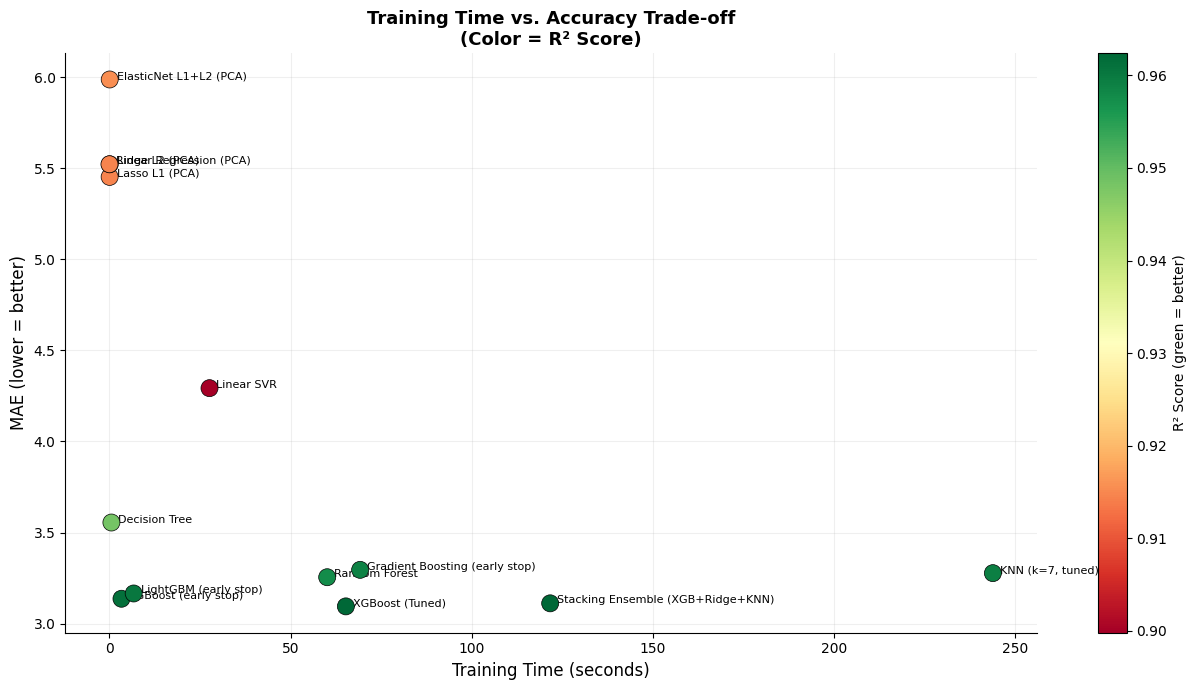

In [ ]:
try:
    from adjustText import adjust_text
    has_adjustText = True
except ImportError:
    has_adjustText = False

timed_df = results_df[results_df['Train Time (s)'] != '—'].copy()
timed_df['Train Time (s)'] = timed_df['Train Time (s)'].astype(float)

fig, ax = plt.subplots(figsize=(13, 7))
scatter = ax.scatter(timed_df['Train Time (s)'], timed_df['MAE'],
                     c=timed_df['R² Score'], cmap='RdYlGn',
                     s=150, zorder=5, edgecolors='black', linewidths=0.5)

if has_adjustText:
    texts = [ax.text(row['Train Time (s)'], row['MAE'], f"  {row['Model']}", fontsize=8.5)
             for _, row in timed_df.iterrows()]
    adjust_text(texts, ax=ax, expand_points=(2.5, 2.5), expand_text=(1.8, 1.8),
                force_points=(0.8, 0.8), arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))
else:
    for _, row in timed_df.iterrows():
        ax.annotate(f"  {row['Model']}", (row['Train Time (s)'], row['MAE']), fontsize=8)

plt.colorbar(scatter, ax=ax, label='R² Score (green = better)')
ax.set_xlabel('Training Time (seconds)', fontsize=12)
ax.set_ylabel('MAE (lower = better)', fontsize=12)
ax.set_title('Training Time vs. Accuracy Trade-off\n(Color = R² Score)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('time_vs_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()


## 18. Error Analysis

### 18.1 Error Profile by Hour of Day

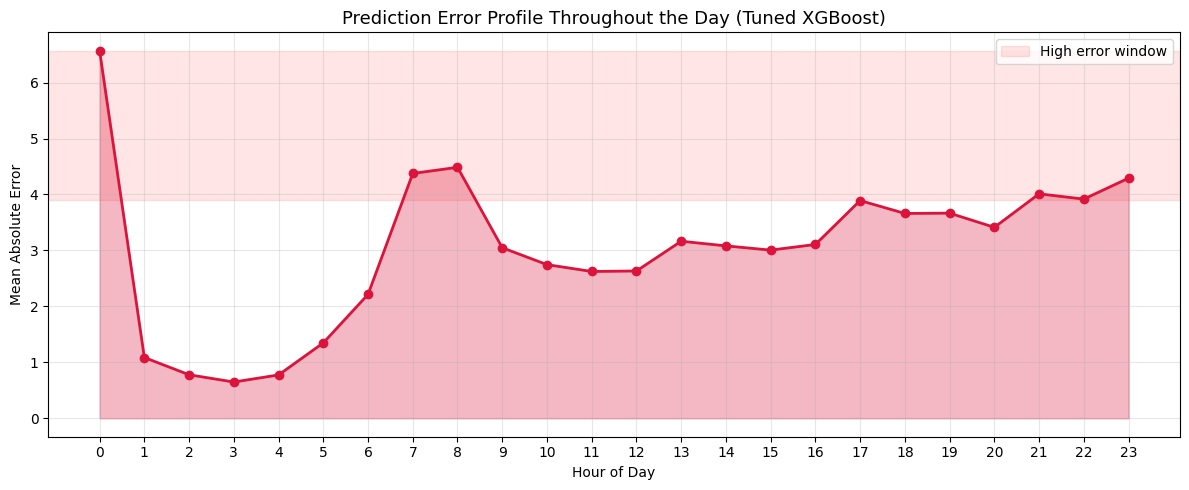

In [ ]:
error_df = X_test.copy()
error_df['actual']    = y_test.values
error_df['predicted'] = best_xgb_preds
error_df['abs_error'] = np.abs(y_test.values - best_xgb_preds)
error_df['hour_num']  = test['hour_num'].values

hourly_err = error_df.groupby('hour_num')['abs_error'].mean()

plt.figure(figsize=(12, 5))
plt.fill_between(hourly_err.index, hourly_err.values, alpha=0.3, color='crimson')
plt.plot(hourly_err.index, hourly_err.values, marker='o', color='crimson', linewidth=2)
plt.axhspan(hourly_err.quantile(0.75), hourly_err.max(), alpha=0.1, color='red', label='High error window')
plt.title('Prediction Error Profile Throughout the Day (Tuned XGBoost)', fontsize=13)
plt.xlabel('Hour of Day')
plt.ylabel('Mean Absolute Error')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()


### 18.2 Top 10 High-Error Zones

Top 10 High-Error Pickup Zones:
              Mean_MAE  Avg_Actual_Demand  Count
PULocationID                                    
186              28.51             163.73    116
138              24.99             125.25    116
132              21.39             167.96    116
239              18.47             138.54    116
48               18.44             107.54    116
142              18.29             148.66    116
68               17.11             129.23    116
107              16.63             100.23    116
79               15.82              86.77    117
140              15.69             126.92    116


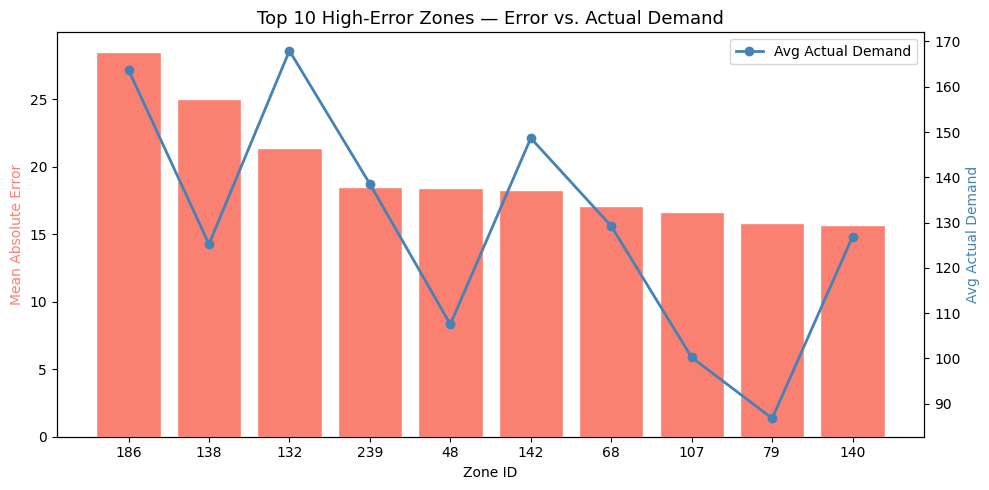

In [ ]:
zone_errors = (error_df.groupby('PULocationID')
               .agg(Mean_MAE=('abs_error', 'mean'),
                    Avg_Actual_Demand=('actual', 'mean'),
                    Count=('abs_error', 'count'))
               .sort_values('Mean_MAE', ascending=False).head(10).round(2))

print("Top 10 High-Error Pickup Zones:")
print(zone_errors.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(zone_errors.index.astype(str), zone_errors['Mean_MAE'], color='salmon', edgecolor='white')
ax2 = ax.twinx()
ax2.plot(zone_errors.index.astype(str), zone_errors['Avg_Actual_Demand'],
         color='steelblue', marker='o', linewidth=2, label='Avg Actual Demand')
ax.set_title('Top 10 High-Error Zones — Error vs. Actual Demand', fontsize=13)
ax.set_xlabel('Zone ID')
ax.set_ylabel('Mean Absolute Error', color='salmon')
ax2.set_ylabel('Avg Actual Demand', color='steelblue')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('error_by_zone.png', dpi=120, bbox_inches='tight')
plt.show()


In [ ]:
mask_132 = test['PULocationID'] == 132
y_132 = y_test[mask_132]
xgb_132 = best_xgb_preds[mask_132]

# Rebuild baseline predictions for zone 132 safely
baseline_132 = test[mask_132].merge(
    baseline_avg, on=['PULocationID', 'hour_num'], how='left'
)['trip_count_y'].fillna(0).values

print(f"XGBoost MAE Zone 132: {np.mean(np.abs(y_132 - xgb_132)):.2f}")
print(f"Baseline MAE Zone 132: {np.mean(np.abs(y_132 - baseline_132)):.2f}")

XGBoost MAE Zone 132: 21.39
Baseline MAE Zone 132: 22.89


### 18.3 Residual Plot (Best Model)

A good model should have residuals randomly scattered around zero.
Any pattern reveals systematic error the model hasn't captured.


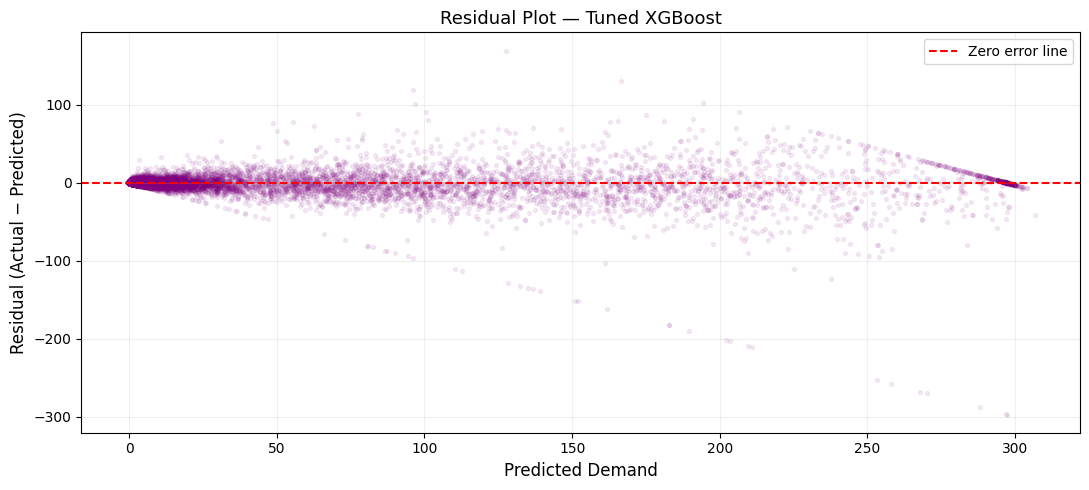

Mean residual    : -0.4585  (close to 0 = unbiased predictions)
Std of residuals : 10.0060


In [ ]:
residuals = y_test.values - best_xgb_preds

plt.figure(figsize=(11, 5))
plt.scatter(best_xgb_preds, residuals, alpha=0.08, color='purple', s=8)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error line')
plt.xlabel('Predicted Demand', fontsize=12)
plt.ylabel('Residual (Actual − Predicted)', fontsize=12)
plt.title('Residual Plot — Tuned XGBoost', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Mean residual    : {residuals.mean():.4f}  (close to 0 = unbiased predictions)")
print(f"Std of residuals : {residuals.std():.4f}")


**The residual plot reveals two patterns:**
1. **Fan shape (heteroscedasticity):** residuals spread wider as predicted demand increases
   (residual std = 10.006, mean = -0.459 ≈ 0 , which confirm unbiased but heteroscedastic predictions).
2. **Negative tail at high values (>200):** the model under-predicts extreme demand peaks, because they are rare in training data which is a structural limitation of one month of data.

**The residual plot confirms heteroscedasticity.** The model is precise for low-demand periods, but exhibits higher variance during peak surges, likely due to missing external "shock" features such as weather events, public holidays, or large gatherings that create sudden demand spikes the model has never seen in training.


## 19. Final Summary & Conclusion

In [ ]:
print("  FINAL PROJECT SUMMARY: Spatio-Temporal Ride Demand")
print("  NYC Yellow Taxi January 2025 Dataset")


results_df_final = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
best_row     = results_df_final.iloc[0]
baseline_row = results_df_final[results_df_final['Model'] == 'Historical Baseline'].iloc[0]

mae_improvement  = ((baseline_row['MAE']  - best_row['MAE'])  / baseline_row['MAE'])  * 100
rmse_improvement = ((baseline_row['RMSE'] - best_row['RMSE']) / baseline_row['RMSE']) * 100

print(f"\n  Best Model   : {best_row['Model']}")
print(f"    MAE          : {best_row['MAE']} trips/zone/hour")
print(f"    RMSE         : {best_row['RMSE']}")
print(f"    R² Score     : {best_row['R² Score']}")
print(f"\n  vs. Historical Baseline")
print(f"    MAE  improved by : {mae_improvement:.1f}%")
print(f"    RMSE improved by : {rmse_improvement:.1f}%")
print(f"\n  Features used    : {len(features)}")
print(f"  Training samples : {len(X_train):,}")
print(f"  Test samples     : {len(X_test):,}")


  FINAL PROJECT SUMMARY: Spatio-Temporal Ride Demand
  NYC Yellow Taxi January 2025 Dataset

  Best Model   : XGBoost (Tuned)
    MAE          : 3.0949 trips/zone/hour
    RMSE         : 10.0165
    R² Score     : 0.9624

  vs. Historical Baseline
    MAE  improved by : 32.7%
    RMSE improved by : 25.8%

  Features used    : 18
  Training samples : 120,383
  Test samples     : 30,096


## Key Findings

1. **Lag features dominate** `lag_1`, `lag_168`, and `lag_24` are the strongest predictors,
   confirming strong temporal autocorrelation in ride demand. Recent history and weekly seasonality
   are the primary drivers of zone-level demand.

2. **PCA reduces multicollinearity for linear models**:  VIF analysis confirmed VIF > 10
   for lag/rolling features. PCA-orthogonalised inputs stabilise regularisation behaviour
   in Ridge/Lasso/ElasticNet. However, linear models still underperformed the Historical
   Baseline (MAE 5.42-5.99 vs 4.60), confirming that taxi demand contains inherently
   non-linear patterns that PCA preprocessing alone cannot compensate for.

3. **Historical baseline is a strong competitor for linear models**: this is expected in
   time-series forecasting: a heuristic that memorises zone-hour patterns directly will naturally
   outperform models that generalise across features. Tree-based models surpass it by capturing
   non-linear interactions the baseline cannot express.

4. **Feature scaling applied correctly and consistently**:  StandardScaler fitted on training
   data only (no leakage). Stacking base models each wrapped in their own preprocessing Pipeline
   to handle the Ridge (PCA features) vs XGBoost/KNN (standard features) mismatch.

5. **RBF-SVM excluded from execution**:  O(n²) kernel memory cost required 8+ minutes on
   a 15% subsample with uncompetitive results. Gradient boosting achieves equivalent non-linear
   expressiveness at a fraction of the cost.

6. **Stacking ensemble adds complexity without meaningful gain**:  XGBoost (Tuned) and the
   Stacking Ensemble (XGB+Ridge+KNN) are statistically indistinguishable (overlapping 95% CI:
   [3.0076, 3.2038] vs [3.0169, 3.2208]). The residual correlation matrix revealed high
   XGBoost-KNN correlation (0.899), limiting the meta-learner's ability to combine truly
   complementary signals. XGBoost is preferred for deployment: simpler, faster, and equally
   accurate within statistical uncertainty.

7. **Early stopping prevents overfitting in boosting models**:  GB, LightGBM, and XGBoost automatically halt when validation performance plateaus, using only the optimal number of estimators.

8. **TimeSeriesSplit CV confirms ranking stability**:  top-3 models validated across 5 temporal folds; XGBoost CV MAE 3.4983 ± 0.2659 confirms the single-split ranking is not a statistical artefact. CV MAE is slightly higher than single-split MAE (3.0949) as expected earlier, folds have less training data, making it the more conservative and honest estimate.

10. **Bootstrap confidence intervals quantify uncertainty**:  MAE reported with 95% CI from 200 bootstrap resamples; overlapping CIs flag model pairs that are not statistically distinguishable (e.g. XGBoost vs Stacking).

11. **MAPE provides interpretable error for stakeholders**: percentage error contextualises MAE for fleet operators who think in relative terms.
High MAPE values (~48%) are partly inflated by near-zero demand zones; zero-demand samples excluded from calculation to avoid division by zero.

12. **Heteroscedasticity remains an acknowledged limitation**: the fan-shaped residual plot confirms error variance grows with demand. High-demand zones (airports, Penn Station) during surge events are structurally underrepresented in one month of training data. Richer features (event calendars, weather data) and log-transformation before PCA will be our priority in future improvements.

---

## Future Work

1. **External shock features**: incorporating weather data, event calendars, and public holiday indicators would directly address the high-error peak periods identified in the residual analysis.

2. **Zone-level models**: training separate models per high-demand zone (airports, Penn Station) could address the systematic under-prediction of surge events in those locations.